In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
import joblib
import warnings

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Ignore warnings for clean execution
warnings.filterwarnings('ignore')

In [4]:
# Load the ARFF dataset
data, meta = arff.loadarff('Lymphoma.arff')
df = pd.DataFrame(data)
target_col = df.columns[-1]

# Decode byte strings to regular strings
if df[target_col].dtype == object:
    df[target_col] = df[target_col].str.decode('utf-8')

# Separate features (X) and target (y)
X = df.drop(columns=[target_col])
y = df[target_col]

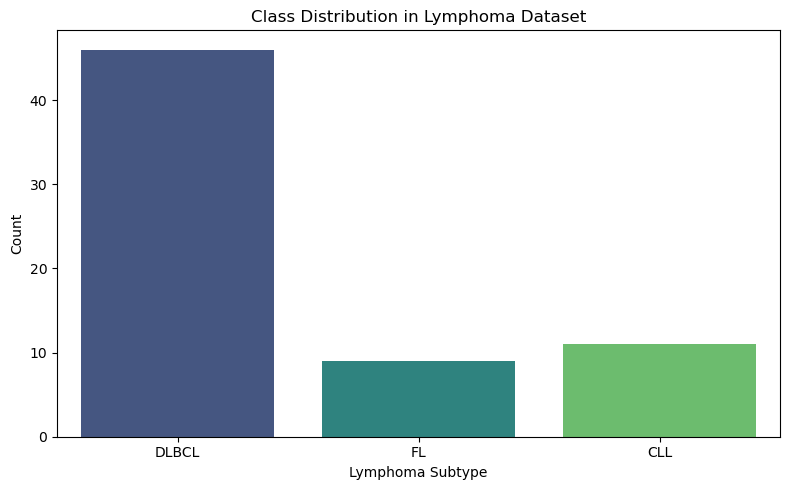

In [5]:
# Plot 1: Class Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=target_col, palette='viridis')
plt.title("Class Distribution in Lymphoma Dataset")
plt.xlabel("Lymphoma Subtype")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("eda_1_class_distribution.png")
plt.show() 
plt.close()

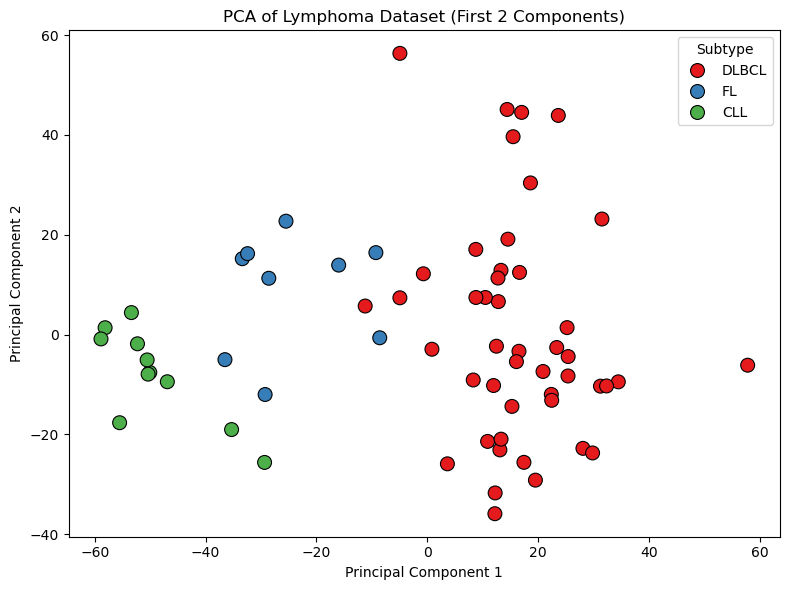

In [6]:
# Plot 2: PCA Dimensionality Reduction
pca_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2))
])
X_pca = pca_pipeline.fit_transform(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='Set1', s=100, edgecolor='k')
plt.title("PCA of Lymphoma Dataset (First 2 Components)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title='Subtype')
plt.tight_layout()
plt.savefig("eda_2_pca_plot.png") 
plt.show() 
plt.close()

In [7]:
# Train/Test Split (70/30, Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Single optimized pipeline using RandomForest
rf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train and Predict
rf_pipeline.fit(X_train, y_train)
y_pred = rf_pipeline.predict(X_test)

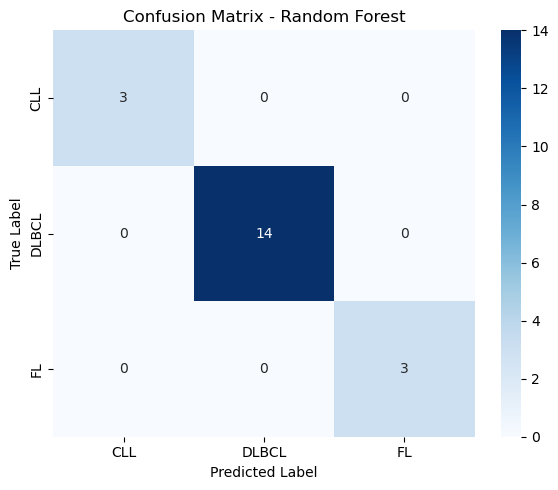

In [8]:
# Plot 3: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_pipeline.classes_, yticklabels=rf_pipeline.classes_)
plt.title("Confusion Matrix - Random Forest")
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig("eval_cm_rf.png") 
plt.show() 
plt.close()

In [9]:
# Calculate Final Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)

# Print Final Evaluation Results
print("=== Final Random Forest Evaluation Results ===")
print(f"Accuracy Score:  {acc:.4f}")
print(f"Precision Score: {prec:.4f}")
print(f"Recall Score:    {rec:.4f}")
print(f"F1 Score:        {f1:.4f}\n")

# Retrain on the FULL dataset to maximize data exposure before deployment
rf_pipeline.fit(X, y)
model_filename = "lymphoma_rf_model.joblib"
joblib.dump(rf_pipeline, model_filename)

print(f"Successfully retrained on full data and saved pipeline to '{model_filename}'")

=== Final Random Forest Evaluation Results ===
Accuracy Score:  1.0000
Precision Score: 1.0000
Recall Score:    1.0000
F1 Score:        1.0000

Successfully retrained on full data and saved pipeline to 'lymphoma_rf_model.joblib'
